In [1]:
%%capture
# Install necessary libraries
!pip install datasets seaborn shap lime interpret transformers

In [2]:
import datasets
import pandas as pd
import seaborn as sns
import transformers
import shap
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import lime
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import numpy as np

# Explainable AI Tutorial

Explailable AI (XAI) aims to enhance transparency of (complex) AI models by clarifying the reasoning behind their predictions, which is crucial for their practical use and widespread adoption, particularly in high-stakes applications (healthcare, legal).

Below we show and look into the details of several examples.


## Inherently interpretable models

Inherently interpretable models are transparent by design.

These models, such as decision trees, linear models, and rule-based systems, make their decision-making process directly visible through simple structures that humans can easily inspect and understand.
Unlike complex neural networks that require additional explanation tools, interpretable models show their logic explicitly: you can trace exactly how each feature contributes to a prediction.

This transparency is particularly valuable in high-stakes applications like healthcare and finance, where understanding why a model made a specific prediction is just as critical as the prediction itself.

We will showcase the decision tree approach on the task of predicting whether breast cancer is malignant or benign using the public breast cancer dataset.

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
# Load data
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = X.columns
target_names = data.target_names

print(X.head(3))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0                 0.07871  ...         25.38          17.33            184.6   
1                 0.05667  ...         24.99          23.41            158.8   
2                 0.05999  ...         23.57          25.53            152.5   

   worst area  worst smoothness  worst compactness  worst concavity  \
0 

In [5]:
# Split data into training and test stratifying on the class
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Train decision tree classifier model
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [6]:
# Inference on the test set and model evaluation
y_pred = tree.predict(X_test)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:

              precision    recall  f1-score   support

   malignant       0.90      0.89      0.90        64
      benign       0.94      0.94      0.94       107

    accuracy                           0.92       171
   macro avg       0.92      0.92      0.92       171
weighted avg       0.92      0.92      0.92       171



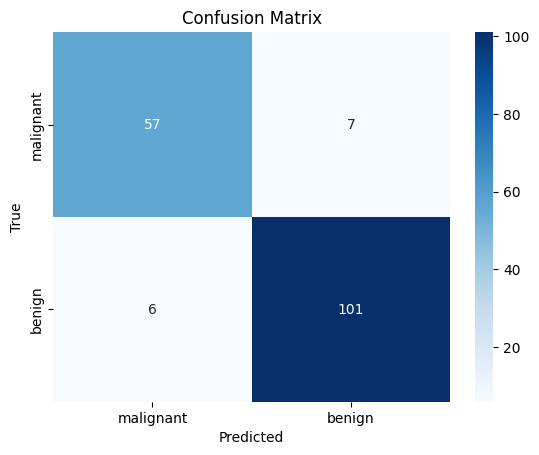

In [7]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

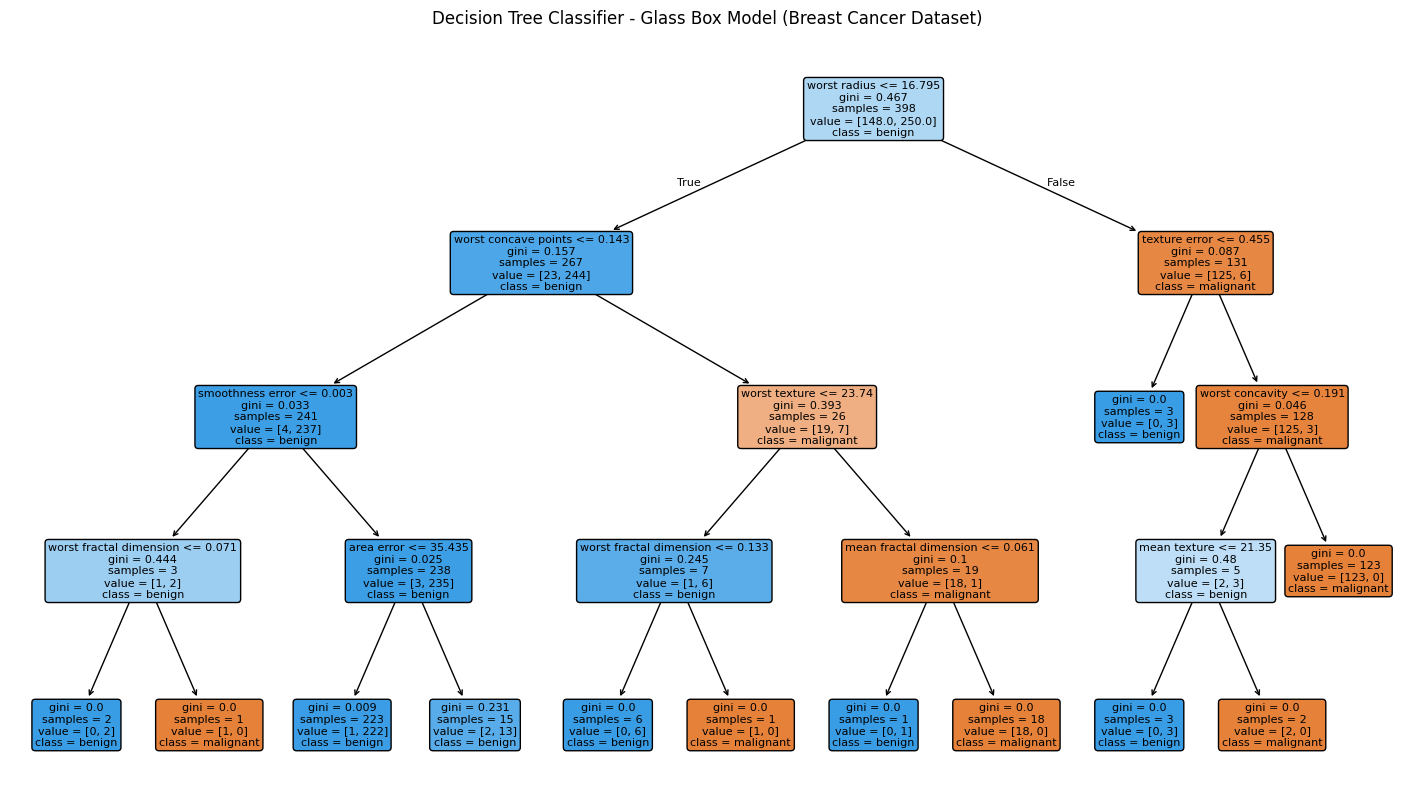

In [8]:
# Visualize the trained decision tree model
plt.figure(figsize=(18, 10))
plot_tree(tree, filled=True, rounded=True,
          feature_names=feature_names,
          class_names=target_names,
          fontsize=8)
plt.title("Decision Tree Classifier - Glass Box Model (Breast Cancer Dataset)")
plt.show()

This tree shows the exact decision logic used by the model. Each node corresponds to a condition using a threshold (e.g., “mean radius ≤ 16.8”) that splits the data in two parts. Each path from the root of the tree to a leaf corresponds to a rule leading to a predicted diagnosis (benign or malignant) and provides a transparent rule-based decision.

This makes the model **transparent** and easy to audit. We can also see which features drive predictions.  
The model’s simplicity also helps detect potential **bias**, for example, if specific features dominate decisions or if thresholds align with measurement artifacts.  
Because all features are numerical, the decision boundaries are clear and easy to interpret visually.

We can also see the numerical values of importances for each of the features:

In [9]:
importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importances:")
display(importances.head(10))


Feature Importances:


,Feature,Importance
20,worst radius,0.733864
27,worst concave points,0.132649
21,worst texture,0.036691
11,texture error,0.030980
26,worst concavity,0.019168
29,worst fractal dimension,0.016887
1,mean texture,0.013298
9,mean fractal dimension,0.010499
14,smoothness error,0.003377
13,area error,0.002586


## Generalized Additive Models (GAMs)

Generalized Additive Models (GAMs) are another class of inherently interpretable models. GAMs model the relationship between features and the target as a sum of shape functions that are typically splines but can also be other models such as neural networks or trees.

**prediction = f₁(x₁) + f₂(x₂) + ... + fₙ(xₙ)**

Each feature contributes independently to the final prediction through its own function. This makes GAMs:
- **Interpretable**: You can visualize how each feature affects predictions through shape functions
- **Flexible**: Unlike linear models, GAMs can capture non-linear relationships
- **Accurate**: Often competitive with more complex models

We'll use **Explainable Boosting Machines (EBM)**, a modern GAM implementation that also supports **GA2M** (pairwise feature interactions), making it even more powerful while maintaining interpretability. EBM models each feature’s contribution using an ensemble of shallow decision trees, which are then aggregated into smooth, human-readable shape functions. This approach allows the model to automatically capture non-linear patterns and subtle thresholds in each feature while preserving clear, additive explanations for every prediction.

In [10]:
%%capture
# interpret library for GAMs
!pip install interpret

In [11]:
# EBM (Explainable Boosting Machine) - a GAM/GA2M implementation
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

### Training the GAM/GA2M Model

We'll train an Explainable Boosting Classifier with:
- **Individual feature contributions** (GAM component)
- **Pairwise interactions** (GA2M component) to capture how features work together

In [12]:
# interactions parameter controls how many pairwise interactions to learn
ebm = ExplainableBoostingClassifier(
    random_state=42,
    interactions=10,  # Learn top 10 pairwise interactions
    max_bins=256,
    n_jobs=-1
)

ebm.fit(X_train, y_train)

ExplainableBoostingClassifier(interactions=10, max_bins=256, n_jobs=-1)

In [13]:
# Evaluate the GAM/GA2M model
y_pred_ebm = ebm.predict(X_test)
print("Classification Report (GAM/GA2M):\n")
print(classification_report(y_test, y_pred_ebm, target_names=target_names))

Classification Report (GAM/GA2M):

              precision    recall  f1-score   support

   malignant       0.98      0.94      0.96        64
      benign       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



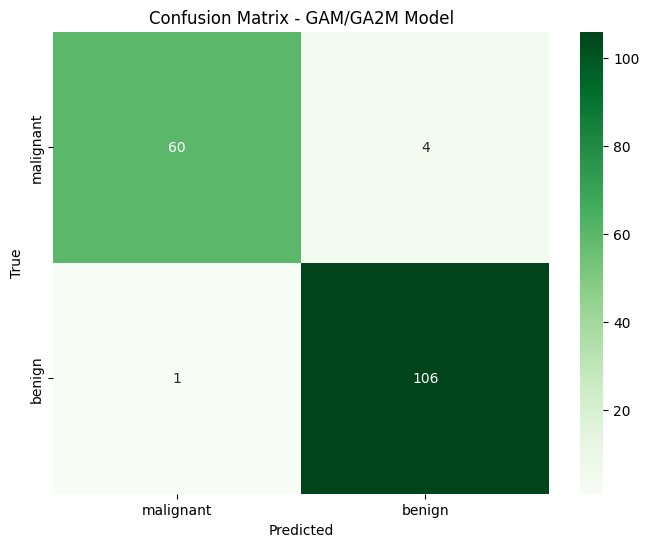

In [14]:
# Confusion matrix for GAM/GA2M
cm_ebm = confusion_matrix(y_test, y_pred_ebm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ebm, annot=True, fmt='d', cmap='Greens', xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix - GAM/GA2M Model")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Feature Importance in GAM

Let's look at the global importance of each feature. This tells us which features contribute most to the model's predictions overall.

In [15]:
# Get feature importances from the EBM model
# includes both individual features and pairwise interactions
ebm_global = ebm.explain_global()

# Extract feature names and their importance scores
feature_importance_data = []
for i, feature_name in enumerate(ebm_global.data()['names']):
    importance = ebm_global.data()['scores'][i]
    feature_importance_data.append({'Feature': feature_name, 'Importance': importance})

ebm_importances = pd.DataFrame(feature_importance_data).sort_values(by='Importance', ascending=False)

print("\nTop 15 Features/Interactions by Importance:")
display(ebm_importances.head(15))


Top 15 Features/Interactions by Importance:


,Feature,Importance
27,worst concave points,2.315171
21,worst texture,1.937053
23,worst area,1.638863
13,area error,1.558167
4,mean smoothness,1.441393
24,worst smoothness,1.389948
22,worst perimeter,1.279131
1,mean texture,1.180791
26,worst concavity,1.080781
20,worst radius,1.006540


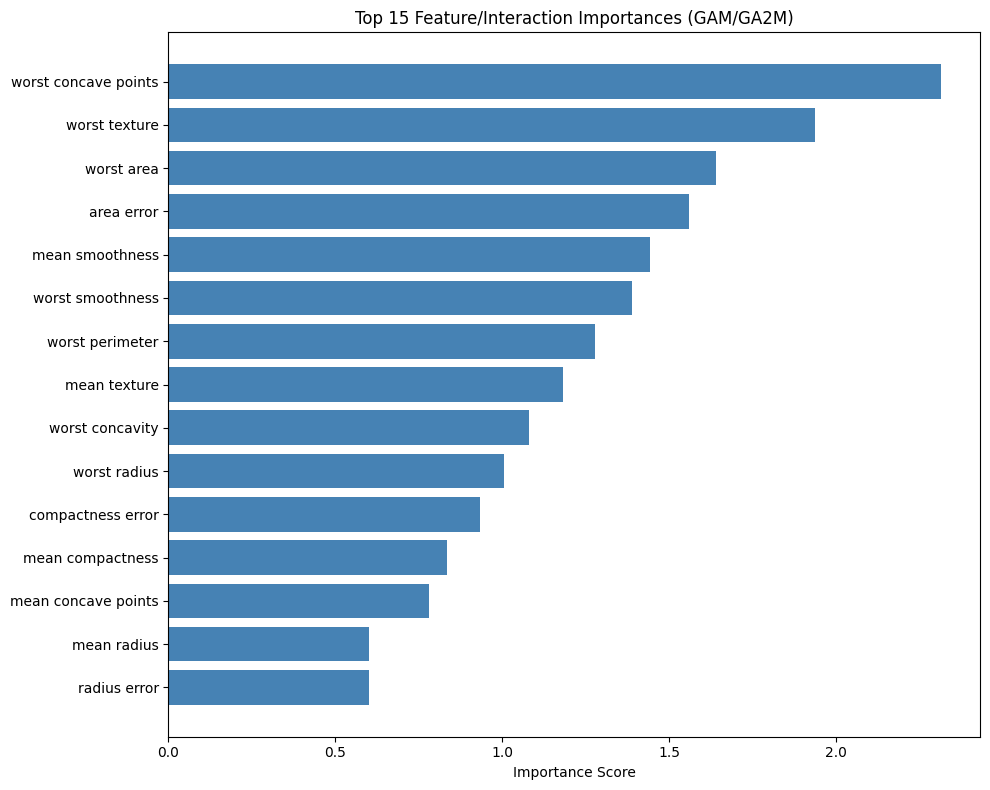

In [16]:
# Visualize feature importances
plt.figure(figsize=(10, 8))
top_features = ebm_importances.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values, color='steelblue')
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 15 Feature/Interaction Importances (GAM/GA2M)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Individual Feature Contributions (Shape Functions)

The power of GAMs is that we can visualize **how** each feature affects predictions. These "shape functions" show:
- **X-axis**: Feature values
- **Y-axis**: Contribution to the prediction (score)
- **Shape**: Non-linear relationships the model learned

Let's visualize the top individual features (not interactions):

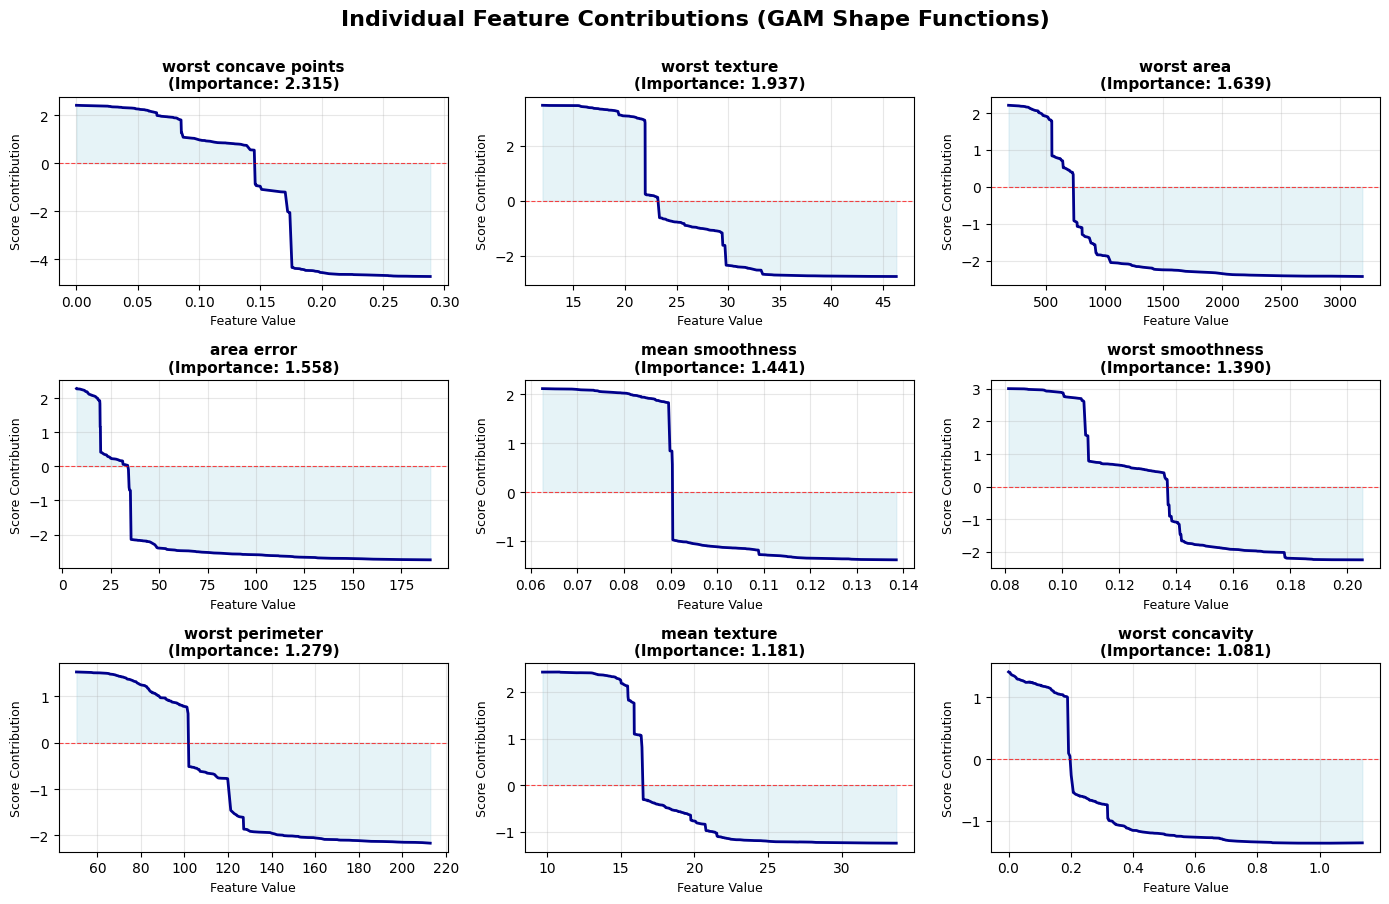

In [17]:
# Filter to get only individual features (not pairwise interactions)
individual_features = ebm_importances[~ebm_importances['Feature'].str.contains(' x ')].head(9)

# Create subplots for the top 9 individual features
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
axes = axes.flatten()

for idx, (_, row) in enumerate(individual_features.iterrows()):
    feature_name = row['Feature']

    # Find the feature index in the EBM model
    feature_idx = list(ebm_global.data()['names']).index(feature_name)

    # Get the data for this feature
    feature_data = ebm_global.data(feature_idx)

    # Plot the shape function
    ax = axes[idx]

    # Get bins and scores
    bins = np.array(feature_data['names'])
    scores = np.array(feature_data['scores'])

    min_len = min(len(bins), len(scores))
    ax.plot(bins[:min_len], scores[:min_len], linewidth=2, color='darkblue')
    ax.fill_between(bins[:min_len], scores[:min_len], alpha=0.3, color='lightblue')


    ax.set_title(f'{feature_name}\n(Importance: {row["Importance"]:.3f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature Value', fontsize=9)
    ax.set_ylabel('Score Contribution', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

plt.suptitle('Individual Feature Contributions (GAM Shape Functions)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

**Interpretation Guide:**
- **Positive scores** (above the red dashed line) push the prediction toward "benign" (class 1)
- **Negative scores** (below the red dashed line) push the prediction toward "malignant" (class 0)
- **Steeper curves** indicate stronger feature effects
- **Flat regions** indicate feature values that don't affect the prediction much

For example, if "worst radius" shows negative scores for high values, it means larger tumor radius increases the likelihood of malignancy.

### GA2M: Pairwise Feature Interactions

While GAMs assume features contribute independently, GA2M extends this by modeling pairwise interactions. Some features may work together in complex ways. For example, the combination of high radius AND high concavity might be more indicative of malignancy than either feature alone.

Let's visualize the learned pairwise interactions as heatmaps:

In [18]:
# Extract pairwise interactions (features with ' x ' in the name)
# In EBM, interactions come after the individual features (indices 30+)

all_feature_names = ebm_global.data()['names']
all_feature_scores = ebm_global.data()['scores']

# Original dataset has 30 features, so interactions start at index 30
n_original_features = len(feature_names)

# Extract interaction features
interaction_list = []
for i in range(n_original_features, len(all_feature_names)):
    fname = all_feature_names[i]
    importance = all_feature_scores[i]

    # Format the name nicely
    if isinstance(fname, tuple):
        display_name = f"{fname[0]} x {fname[1]}"
    else:
        display_name = str(fname).replace(' & ', ' x ')

    interaction_list.append({
        'Feature': display_name,
        'Importance': importance,
        'FeatureIdx': i  # Store the actual EBM feature index
    })

# Create DataFrame and sort by importance
interactions_df = pd.DataFrame(interaction_list).sort_values(by='Importance', ascending=False)

print(f"\nFound {len(interaction_list)} pairwise interactions")
print(f"\nTop 10 Pairwise Interactions:")
display(interactions_df[['Feature', 'Importance']].head(10))


Found 10 pairwise interactions

Top 10 Pairwise Interactions:


,Feature,Importance
5,worst texture x worst concave points,0.324487
1,smoothness error x worst area,0.238056
3,concave points error x worst concave points,0.195530
8,worst area x worst symmetry,0.190234
2,compactness error x worst concave points,0.184469
4,worst radius x worst smoothness,0.179124
7,worst area x worst smoothness,0.174979
6,worst perimeter x worst smoothness,0.172748
0,smoothness error x worst radius,0.164670
9,worst smoothness x worst fractal dimension,0.125031


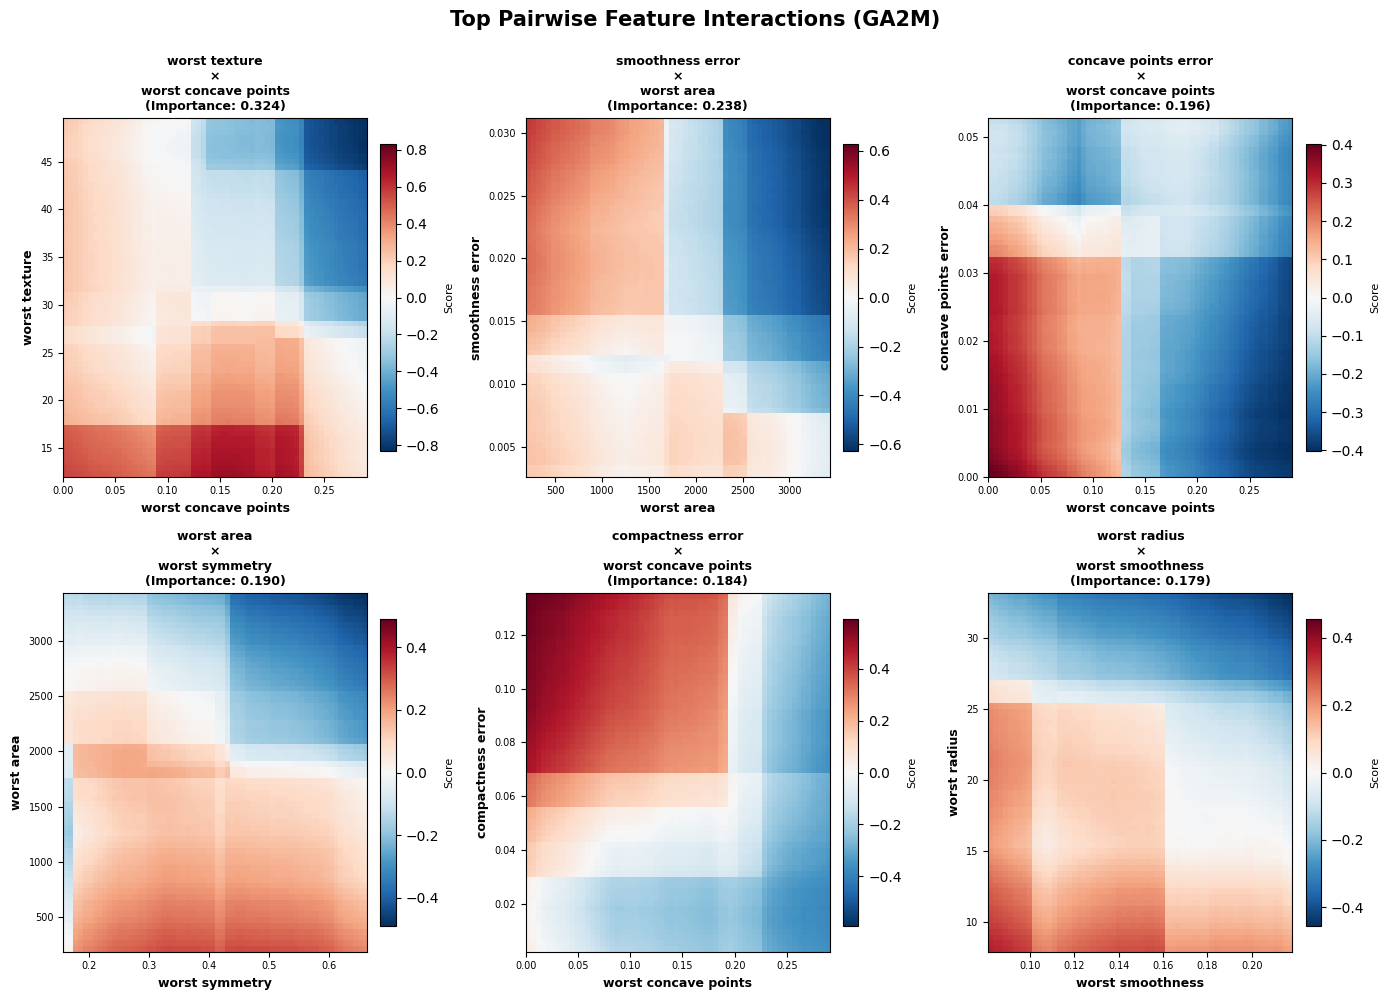

In [19]:
# Visualize the top pairwise interactions as heatmaps
n_interactions = min(6, len(interactions_df))

if n_interactions == 0:
    print("No pairwise interactions found in the model.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(14, 10))
    axes = axes.flatten()

    top_interactions = interactions_df.head(n_interactions)

    for plot_idx, (df_idx, row) in enumerate(top_interactions.iterrows()):
        feature_name = row['Feature']
        ebm_feature_idx = row['FeatureIdx']  # actual index in EBM model

        # Get interaction data from EBM
        interaction_data = ebm_global.data(ebm_feature_idx)

        # Extract the 2D score matrix
        scores = interaction_data['scores']
        heatmap_data = np.array(scores)

        ax = axes[plot_idx]

        # Get feature value ranges from bin edges
        left_bins = interaction_data['left_names']
        right_bins = interaction_data['right_names']

        # Set extent to map image coordinates to actual feature values
        # extent = [left, right, bottom, top] for the image
        extent = [right_bins[0], right_bins[-1], left_bins[0], left_bins[-1]]

        vmax = max(abs(heatmap_data.min()), abs(heatmap_data.max()))
        if vmax == 0:
            vmax = 1
        vmin = -vmax

        # Create heatmap with extent to show real feature values on axes
        im = ax.imshow(heatmap_data, cmap='RdBu_r', aspect='auto', interpolation='nearest', vmin=vmin, vmax=vmax, origin='lower', extent=extent)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Score', fontsize=8)

        # Parse feature names for labels

        parts = feature_name.split(' x ')
        feature1_name = parts[0]
        feature2_name = parts[1]

        ax.set_ylabel(feature1_name, fontsize=9, fontweight='bold')
        ax.set_xlabel(feature2_name, fontsize=9, fontweight='bold')
        title = f'{feature1_name}\n×\n{feature2_name}\n(Importance: {row["Importance"]:.3f})'
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.ticklabel_format(style='plain', useOffset=False)
        ax.tick_params(axis='both', labelsize=7)


    plt.suptitle('Top Pairwise Feature Interactions (GA2M)', fontsize=15, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()


**Heatmap Interpretation:**
- Each cell represents a combination of binned values for the two interacting features
- **Red colors** indicate combinations that increase malignancy risk (negative score contribution)
- **Blue colors** indicate combinations that increase benign likelihood (positive score contribution)
- **White/neutral** colors indicate little interaction effect

These heatmaps reveal synergistic effects between features that wouldn't be captured by looking at features in isolation.

### Summary

Let's compare the three interpretable models:

- Decision tree has simple rules, moderate flexibility and is best for quick insights and categorical decisions.
- GAM model smooth functions, has a higher flexibility and can be used for understanding individual feature effects.
- GA2M models pairwise interactions understanding relationships between features.